In [1]:
import numpy as np
import pandas as pd

%matplotlib inline
import matplotlib.pyplot as plt

events = pd.read_csv("events.dat", sep=" ")
events["chirp_mass"] = (events["mass_1"] * events["mass_2"])**0.6 / (events["mass_1"] + events["mass_2"])**0.2
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [2]:
def quantile_list(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"em_posteriors/source_{j}/posterior.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

def mass_quantiles(key):
    quantiles = np.zeros(events.shape[0])
    for j in range(events.shape[0]):
    
        posterior = np.load(f"gw_posteriors/source_{j}/posterior_mm.npz")
    
        quantiles[j] = np.sum(posterior[key]<=events.loc[j, key]) / posterior[key].shape[0]

    return quantiles

quantiles = quantile_list("log10_mej_dyn")
quantiles_m1 = mass_quantiles("mass_1_source")
quantiles_m2 = mass_quantiles("mass_2_source")

(array([0.52959246, 1.05918492, 2.11836985, 0.52959246, 1.32398115,
        2.38316608, 2.64796231, 0.52959246, 0.79438869, 1.58877738]),
 array([0.177584 , 0.2516328, 0.3256816, 0.3997304, 0.4737792, 0.547828 ,
        0.6218768, 0.6959256, 0.7699744, 0.8440232, 0.918072 ]),
 [<matplotlib.patches.Polygon at 0x7f7856565510>])

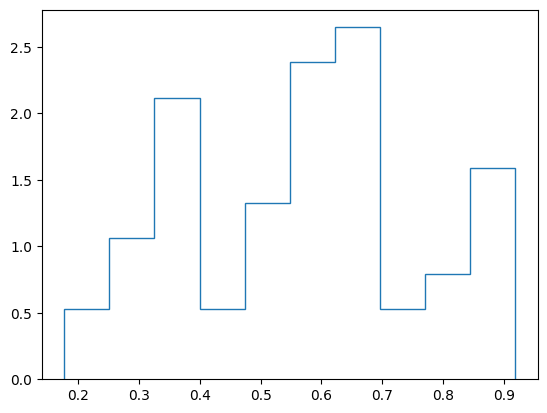

In [5]:

plt.hist(quantiles, histtype="step", density=True)


In [2]:
for j in range(events.shape[0]):

    gw_file = f"./gw_posteriors/source_{j}/posterior_mm.npz"
    gw_posterior = dict(np.load(gw_file, allow_pickle=True))
    gw_posterior["cos_theta_jn"] = np.cos(gw_posterior["theta_jn"])
    np.savez(gw_file, **gw_posterior)
    
    em_file = f"./em_posteriors/source_{j}/posterior.npz"
    em_posterior = dict(np.load(em_file, allow_pickle=True))
    upside_downside = np.random.choice([-1, 1], size=(em_posterior["inclination_EM"].shape[0],))
    em_posterior["cos_theta_jn"] = upside_downside * np.cos(em_posterior["inclination_EM"])
    np.savez(em_file, **em_posterior)
